In [1]:
import pandas as pd
import numpy as np
import sys
import gseapy as gp
from typing import Dict, Optional, Tuple, Any, List
import math
import json
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
from scipy.stats import spearmanr
import seaborn as sns

sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.metadata import MetaData
dataset_dict = {}
original_data = pd.read_csv("Data/original_data.csv", index_col = 0)
dataset_dict["Origin"] = original_data
seed = 42
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"Data/{syn_datas[i]}.csv", index_col = 0)
    dataset_dict[tool] = syn_df


mapped_dataset = {}
with open("ssGSEA/mapping_genes.json", "r") as f:
    genes_mapping = json.load(f)
    
abnormal_counts = []
nan_counts = []
for k, v in genes_mapping.items():
    if isinstance(v[0], float) and math.isnan(v[0]):
        nan_counts.append([k, v])
        abnormal_counts.append([k,v])
    elif len(v) > 1 and isinstance(v[0], str):
        abnormal_counts.append([k,v])
        genes_mapping[k]=[v[0]]
            
def ensembl_to_hugo(col, mapping):
    ensembl_id = col.split('.')[0]  # Remove version
    hugo = mapping.get(ensembl_id, [col])  # fallback: leave as is if not found
    return str(hugo[0])
    

for k in nan_counts:
    genes_mapping.pop(k[0], None)

genes_cols = []
for col in original_data.columns:
    if col.startswith("ENSG"):
        genes_cols.append(col)
        
symbols_dataset_dict = {}
for tool, data in dataset_dict.items():
    genes_exp_df = data[genes_cols]
    # Rename column
    genes_exp_df_mapped = genes_exp_df.copy()
    genes_exp_df_mapped.columns = [ensembl_to_hugo(col, genes_mapping) for col in genes_exp_df_mapped.columns]
    
    drop_cols = [col for col in genes_exp_df_mapped.columns if col.startswith("ENSG")]
    genes_exp_df_mapped = genes_exp_df_mapped.drop(columns = drop_cols)
    
    genes_exp_df_mapped_t =genes_exp_df_mapped.T.reset_index()
    genes_exp_df_mapped_t.columns.values[0] = 'Gene'
    
    #Avaraging duplicated genes
    genes_exp_df_mapped_t_grouped = genes_exp_df_mapped_t.groupby("Gene", as_index=False).mean()
    symbols_dataset_dict[tool] = genes_exp_df_mapped_t_grouped

In [22]:
from scipy.stats import ranksums
from statsmodels.sandbox.stats.multicomp import multipletests
from tqdm import tqdm
from joblib import Parallel, delayed
import numpy as np
import pandas as pd

def degs_analysis(gene_expressions, metadata, phenotypes, id_col, n_jobs=-1, verbose=0):
    """
    Differential expression (per-gene) using Wilcoxon rank-sum (ranksums).
    Improved edge-case handling:
      - Detect columns / groups containing both +inf and -inf -> mark and skip tests.
      - Detect negative finite means -> mark and set Log2FC to NaN.
      - Robust removal of NaN/inf before testing.
    Execution remains parallel (joblib) for speed.
    """

    ph_column, ph_values = next(iter(phenotypes.items()))
    if len(ph_values) != 2:
        raise ValueError(f"Phenotype values list must contain exactly two values, got: {ph_values}")

    phenotype_A, phenotype_B = ph_values

    phenotypeA_samples = metadata[metadata[ph_column] == phenotype_A][id_col].values.tolist()
    phenotypeB_samples = metadata[metadata[ph_column] == phenotype_B][id_col].values.tolist()

    if len(phenotypeA_samples) == 0 or len(phenotypeB_samples) == 0:
        raise ValueError("One of the phenotype groups has no samples.")

    phenotypeA_DF = gene_expressions.loc[phenotypeA_samples, :]
    phenotypeB_DF = gene_expressions.loc[phenotypeB_samples, :]

    genelist = gene_expressions.columns.tolist()

    def process_gene(gene):
        # Grab raw arrays (may be any dtype)
        phenotypeA_exp = np.asarray(phenotypeA_DF[gene].values)
        phenotypeB_exp = np.asarray(phenotypeB_DF[gene].values)

        status = []

        # Quick checks for +inf / -inf presence (use np.isposinf / np.isneginf)
        try:
            posinf_A = np.isposinf(phenotypeA_exp).any()
            neginf_A = np.isneginf(phenotypeA_exp).any()
            posinf_B = np.isposinf(phenotypeB_exp).any()
            neginf_B = np.isneginf(phenotypeB_exp).any()
        except Exception:
            # If dtype not numeric (object with strings), coerce to numeric with coercion to NaN,
            # then check again. This is slightly slower but rare if inputs are numeric.
            phenotypeA_exp = np.array(pd.to_numeric(phenotypeA_exp, errors="coerce"), dtype=float)
            phenotypeB_exp = np.array(pd.to_numeric(phenotypeB_exp, errors="coerce"), dtype=float)
            posinf_A = np.isposinf(phenotypeA_exp).any()
            neginf_A = np.isneginf(phenotypeA_exp).any()
            posinf_B = np.isposinf(phenotypeB_exp).any()
            neginf_B = np.isneginf(phenotypeB_exp).any()

        # If a group contains both +inf and -inf, mark and skip testing for that gene.
        if posinf_A and neginf_A:
            status.append("A_contains_posinf_and_neginf")
        if posinf_B and neginf_B:
            status.append("B_contains_posinf_and_neginf")

        # Remove NaNs first
        nonnan_A = phenotypeA_exp[~np.isnan(phenotypeA_exp)]
        nonnan_B = phenotypeB_exp[~np.isnan(phenotypeB_exp)]

        # If we previously saw both +inf and -inf in a group, ranksums with infinities is meaningless.
        # Mark pvalue/log2fc as NaN and return early (but still compute any additional status).
        if ("A_contains_posinf_and_neginf" in status) or ("B_contains_posinf_and_neginf" in status):
            # still compute finite-mean if possible to provide extra info, but set outputs to NaN
            finite_A = nonnan_A[np.isfinite(nonnan_A)] if nonnan_A.size else np.array([], dtype=float)
            finite_B = nonnan_B[np.isfinite(nonnan_B)] if nonnan_B.size else np.array([], dtype=float)
            mean_A = np.nanmean(finite_A) if finite_A.size else np.nan
            mean_B = np.nanmean(finite_B) if finite_B.size else np.nan

            # If finite means exist and are negative, add Mean_negative status
            if (not np.isnan(mean_A) and mean_A < 0) or (not np.isnan(mean_B) and mean_B < 0):
                status.append("Mean_negative")

            pvalue = np.nan
            log2fc = np.nan
            if not status:
                status = ["ok"]
            return pvalue, log2fc, ";".join(status)

        # Remove infinities as well for downstream testing/means
        cleaned_A = nonnan_A[np.isfinite(nonnan_A)]
        cleaned_B = nonnan_B[np.isfinite(nonnan_B)]

        # If after removing NaN/inf there is no data -> No_data
        if cleaned_A.size == 0 or cleaned_B.size == 0:
            pvalue = np.nan
            status.append("No_data")
            mean_A = np.nan
            mean_B = np.nan
        else:
            # If both constant and identical -> p = 1
            if np.all(cleaned_A == cleaned_A[0]) and np.all(cleaned_B == cleaned_B[0]) and cleaned_A[0] == cleaned_B[0]:
                pvalue = 1.0
                status.append("Identical")
            else:
                # ranksums on cleaned finite arrays
                try:
                    _, pvalue = ranksums(cleaned_A, cleaned_B, alternative='two-sided')
                    if np.isnan(pvalue):
                        status.append("p_nan")
                except Exception as e:
                    pvalue = np.nan
                    status.append(f"ranksums_error:{str(e)}")

            mean_A = np.nanmean(cleaned_A) if cleaned_A.size else np.nan
            mean_B = np.nanmean(cleaned_B) if cleaned_B.size else np.nan

        # New edge case: negative finite means -> mark and set Log2FC = NaN
        if (not np.isnan(mean_A) and mean_A < 0) or (not np.isnan(mean_B) and mean_B < 0):
            status.append("Mean_negative")
            log2fc = np.nan
        else:
            # Existing safe Log2FC handling (including divide-by-zero and both-zero)
            if np.isnan(mean_A) or np.isnan(mean_B):
                log2fc = np.nan
                if "FC_nan" not in status:
                    status.append("FC_nan")
            elif mean_A == mean_B == 0:
                log2fc = 0.0
                status.append("FC_both_zero")
            elif mean_B == 0:
                log2fc = np.inf if mean_A > 0 else np.nan
                status.append("FC_div_zero")
            elif mean_A == 0:
                log2fc = -np.inf if mean_B > 0 else np.nan
                status.append("FC_div_zero")
            else:
                # Normal case
                # Protect against negative/zero although we've checked negatives above
                try:
                    log2fc = np.log2(mean_A / mean_B)
                except Exception:
                    log2fc = np.nan
                    status.append("FC_error")

        if not status:
            status = ["ok"]
        return pvalue, log2fc, ";".join(status)

    # Parallel processing (keep genelist order)
    results = Parallel(n_jobs=n_jobs, verbose=verbose)(
        delayed(process_gene)(gene) for gene in genelist
    )
    pvalues, log2FCs, statusflags = zip(*results)

    results_df = pd.DataFrame(
        {
            "Gene": genelist,
            "P_value": pvalues,
            "Log2FC": log2FCs,
            "Status": statusflags,
        }
    )

    # Multiple testing correction (protect against all-NaN p-values)
    pvalues_arr = np.asarray(results_df["P_value"].values)
    valid_p_mask = ~pd.isnull(pvalues_arr)
    valid_pvalues = pvalues_arr[valid_p_mask]
    qvalues = np.full_like(pvalues_arr, np.nan, dtype=np.double)
    if valid_pvalues.size > 0:
        _, qvals_valid, _, _ = multipletests(valid_pvalues, method='fdr_bh')
        qvalues = np.array(qvalues)
        qvalues[valid_p_mask] = qvals_valid

    results_df['Q_value'] = qvalues
    # Rank_Score is only computed for valid Log2FC and Q_value
    results_df["Rank_Score"] = np.where(
        pd.isnull(results_df["Log2FC"]) | pd.isnull(results_df["Q_value"]),
        np.nan,
        (results_df["Log2FC"]) * (-np.log10(results_df["Q_value"]))
    )
    return results_df

In [23]:
degs_results = {}
for name, data in dataset_dict.items():
    print(f"----DEGs Analysis {name} ----")
    # genelist = data.columns.tolist()[54:-1]
    gene_expressions_t = symbols_dataset_dict[name].T
    gene_expressions_t = pd.DataFrame(gene_expressions_t.values[1:], columns=gene_expressions_t.values[0], index =gene_expressions_t.index[1:])
    gene_expressions_t = gene_expressions_t.apply(pd.to_numeric, errors="coerce")
    metadata = pd.DataFrame(
        {"Patient": data.index,
        "PBRM1": data['PBRM1'].values.tolist()}
    )
    # gene_expressions = data[genelist]
    id_col = "Patient"
    phenotypes = {"PBRM1": ["MUT","WT"]}
    degs_df = degs_analysis(gene_expressions_t, metadata, phenotypes, id_col, n_jobs=-1, verbose=0)
    # degs_df.to_csv(f"DEGs/DEGs_{name}_{seed}.csv", index = False)
    degs_results[name] = degs_df

----DEGs Analysis Origin ----
----DEGs Analysis avatarsk5_42 ----
----DEGs Analysis avatarsk10_42 ----
----DEGs Analysis ctgan_42 ----
----DEGs Analysis gaussiancopula_42 ----
----DEGs Analysis synthpop_42 ----
----DEGs Analysis tvae_42 ----


ValueError: One of the phenotype groups has no samples.

In [25]:
degs_results['gaussiancopula_42'].sort_values(by='Log2FC')

,Gene,P_value,Log2FC,Status,Q_value,Rank_Score
22715,RNU1-62P,0.083357,-43.183919,ok,0.530824,-11.877713
6158,ECEL1P2,0.138708,-40.754079,ok,0.613552,-8.645913
3460,CDHR18P,0.300231,-38.035342,ok,0.760854,-4.514745
25057,SAMMSON,0.566060,-37.900257,ok,0.892656,-1.869086
8421,GK2,0.986126,-34.839805,ok,0.998598,-0.021223
...,...,...,...,...,...,...
30041,UBFD1P1,0.714972,NaN,Mean_negative,0.941991,NaN
30538,VN1R70P,0.445661,NaN,Mean_negative,0.840932,NaN
30539,VN1R71P,0.428081,NaN,Mean_negative,0.832683,NaN
30683,WASF3-AS1,0.406684,NaN,Mean_negative,0.821551,NaN


In [27]:
Angio = ['VEGFA','KDR','ESM1','ANGPTL4','CD34']
# Teff = ['CD8A','EOMES','PRF1','IFNG','CD274']
Myeloid = ['IL6', 'CXCL1', 'CXCL2', 'CXCL3', 'CXCL8', 'PTGS2']
Javelin = ['CD3G', 'CD3E', 'CD8B', 'THEMIS', 'TRAT1', 'GRAP2', 'CD247', 'CD2', 'CD96', 'PRF1', 'CD6', 'IL7R', 'ITK', 'GPR18', 'EOMES', 
           'SIT1', 'NLRC3', 'CD244', 'KLRD1', 'SH2D1A', 'XCL2', 'CST7', 'GFI1', 'KCNA3', 'PSTPIP1']
TIS = ['PSMB10', 'HLA-DQA1', 'HLA-DRB1', 'CMKLR1', 'HLA-E', 'NKG7', 'CD8A', 'CXCL9', 'CD27', 'CXCR6', 'IDO1', 
       'STAT1', 'TIGIT', 'LAG3', 'CD274', 'PDCD1LG2', 'CD276']
MHC1 = ['HLA-A', 'HLA-B', 'HLA-C', 'HLA-E', 'HLA-F', 'TAP1', 'TAP2', 'B2M']
MHC2 = [
'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1',
'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1',
'HLA-DRB5']
# degs_results['Origin'][degs_results['Origin']['Gene'].isin(TIS)]

In [28]:
from typing import List, Optional, Dict, Tuple, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_volcano(
    df: pd.DataFrame,
    gene_col: str = 'Gene',
    log2fc_col: str = 'Log2FC',
    pval_col: str = 'P_value',
    pval_thresh: float = 0.05,
    highlight_groups: Optional[Dict[str, List[str]]] = None,
    group_colors: Optional[Dict[str, str]] = None,
    annotate: bool = True,
    figsize: Tuple[int, int] = (8, 6),
    point_size: int = 20,
    alpha: float = 0.7,
    background_color: str = "#bdbdbd",
    edge_color: str = "k",
    title: str = "Volcano plot",
    savepath: Optional[str] = None,
    ax: Optional[plt.Axes] = None,
    xlim: Optional[Tuple[float, float]] = None,
) -> plt.Figure:
    """
    Create a generalized volcano plot.

    Parameters
    ----------
    df : pd.DataFrame
        Table containing gene names, log2 fold changes and p-values.
    gene_col, log2fc_col, pval_col : str
        Column names for gene, log2FC and p-value.
    pval_thresh : float
        Dashed line at -log10(pval_thresh).
    highlight_groups : dict[str, list[str]]
        Mapping: group label → list of gene names to highlight.
    group_colors : dict[str, color]
        Mapping: group label → matplotlib color (must match highlight_groups keys).
    annotate : bool
        Annotate highlighted genes' names.
    figsize : tuple
        Figure size.
    point_size : int
        Scatter point size.
    alpha : float
        Scatter alpha.
    background_color : color
        Color for "other" genes.
    edge_color : color
        Outline color for highlighted groups.
    title : str
        Plot title.
    savepath : str or None
        If provided, saves the figure.
    ax : matplotlib.axes.Axes or None
        If provided, draw on this axis and return its figure.
    xlim : tuple, optional
        (min, max) limits for log2FC (x-axis).

    Returns
    -------
    matplotlib.figure.Figure
    """
    # Defaults
    if highlight_groups is None:
        highlight_groups = {}
    if group_colors is None:
        group_colors = {}
    if isinstance(bg := background_color, dict):  # allow user to pass a colors dict with "background" key
        background_color = bg.get("background", "#bdbdbd")

    # Validate required columns
    for col in (gene_col, log2fc_col, pval_col):
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in DataFrame.")

    plot_df = df.copy()
    plot_df[log2fc_col] = pd.to_numeric(plot_df[log2fc_col], errors='coerce')
    plot_df[pval_col] = pd.to_numeric(plot_df[pval_col], errors='coerce')
    plot_df = plot_df.dropna(subset=[log2fc_col, pval_col], how='any')

    tiny = 1e-300
    pvals = plot_df[pval_col].to_numpy(dtype=float)
    pvals_safe = np.where(np.isnan(pvals), np.nan, np.maximum(pvals, tiny))
    minus_log10_p = -np.log10(pvals_safe)

    # Actual plot
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    sns.set_style("whitegrid")

    # Draw background
    ax.scatter(
        plot_df[log2fc_col],
        minus_log10_p,
        c=background_color,
        s=point_size,
        alpha=alpha,
        edgecolors='none',
        label='Other genes',
        zorder=2
    )

    gene_list = plot_df[gene_col].astype(str).tolist()
    gene_index_map = {g: i for i, g in enumerate(gene_list)}

    legend_handles = []
    used_labels = set()

    # Overlay each highlight group
    for group, hgenes in highlight_groups.items():
        color = group_colors.get(group, "#d62728")
        present = [g for g in hgenes if g in gene_index_map]
        if not present:
            continue
        idxs = [gene_index_map[g] for g in present]
        sc = ax.scatter(
            plot_df.iloc[idxs][log2fc_col],
            minus_log10_p[idxs],
            c=color,
            s=point_size * 1.6,
            alpha=1.0,
            edgecolors=edge_color,
            linewidths=0.6,
            label=group,
            zorder=3
        )
        if group not in used_labels:
            legend_handles.append(sc)
            used_labels.add(group)

        if annotate:
            for g in present:
                i = gene_index_map[g]
                x = plot_df.iloc[i][log2fc_col]
                y = minus_log10_p[i]
                dx = 0.02 * (1 if (hash(g) % 2 == 0) else -1)
                dy = 0.02 * (y if y != 0 else 1.0)
                ax.text(x + dx, y + dy, g, fontsize=9, color=color, weight='bold',
                        ha='left' if dx > 0 else 'right', va='bottom', zorder=10)

    # Guides
    y_thresh = -np.log10(max(pval_thresh, tiny))
    ax.axhline(y=y_thresh, color='grey', linestyle='--', linewidth=1, zorder=1)
    ax.axvline(x=0.0, color='grey', linestyle='--', linewidth=1, zorder=1)

    ax.set_xlabel("Log2 Fold Change", fontsize=12)
    ax.set_ylabel("-log10(P-value)", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')

    # Legend: only group scatter handles + background
    handles, labels = ax.get_legend_handles_labels()
    background_label = "Other genes"
    from matplotlib.lines import Line2D
    handles_final = [Line2D([0], [0], marker='o', color='w', markerfacecolor=background_color,
                            markersize=np.sqrt(point_size), label=background_label, alpha=alpha)]
    # order: background, highlighted groups (may have >2)
    handles_final += [h for h in legend_handles]
    ax.legend(handles=handles_final, loc='upper right', frameon=True)

    if xlim is not None:
        ax.set_xlim(*xlim)

    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')

    return fig

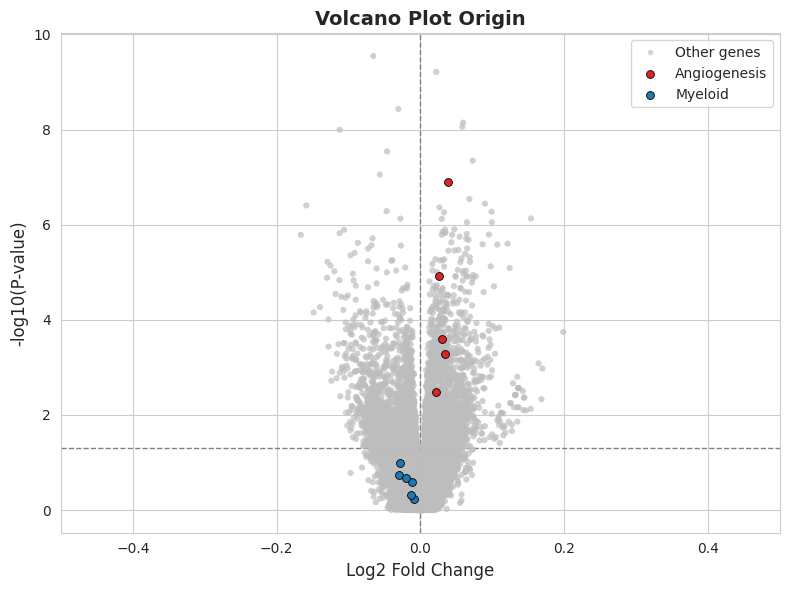

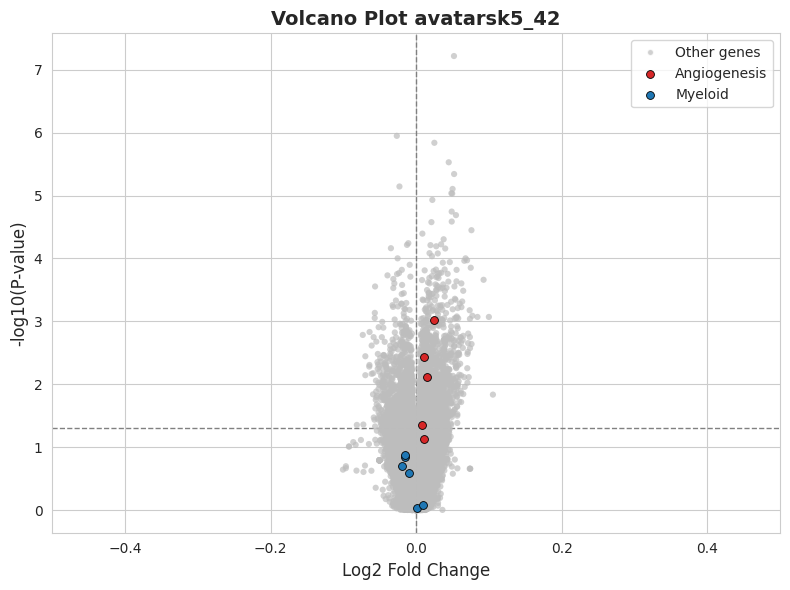

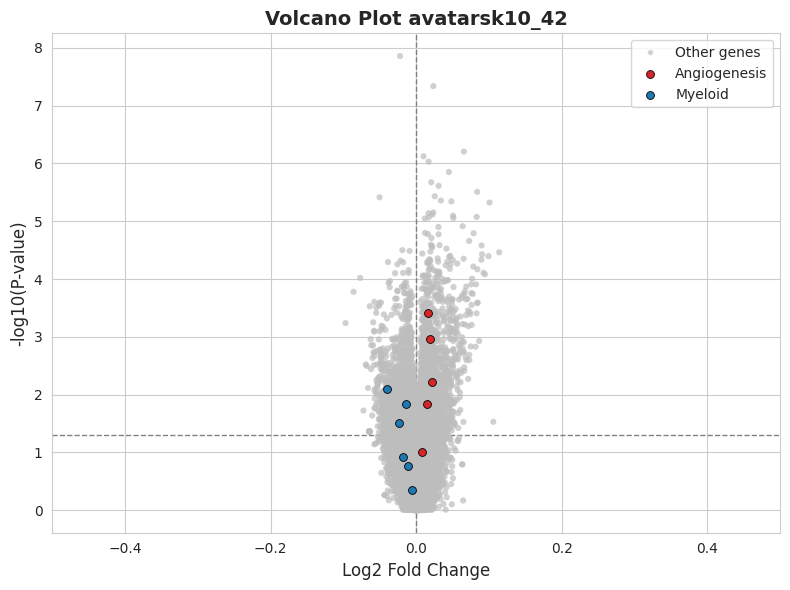

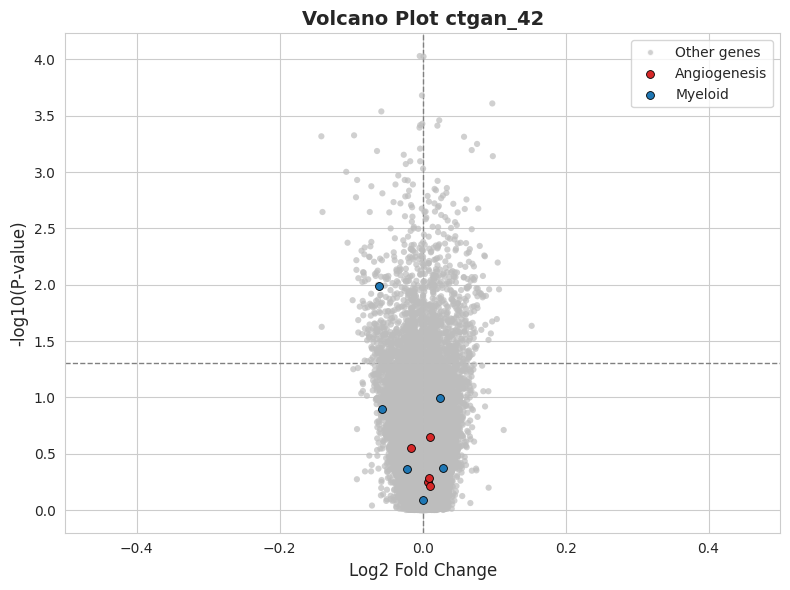

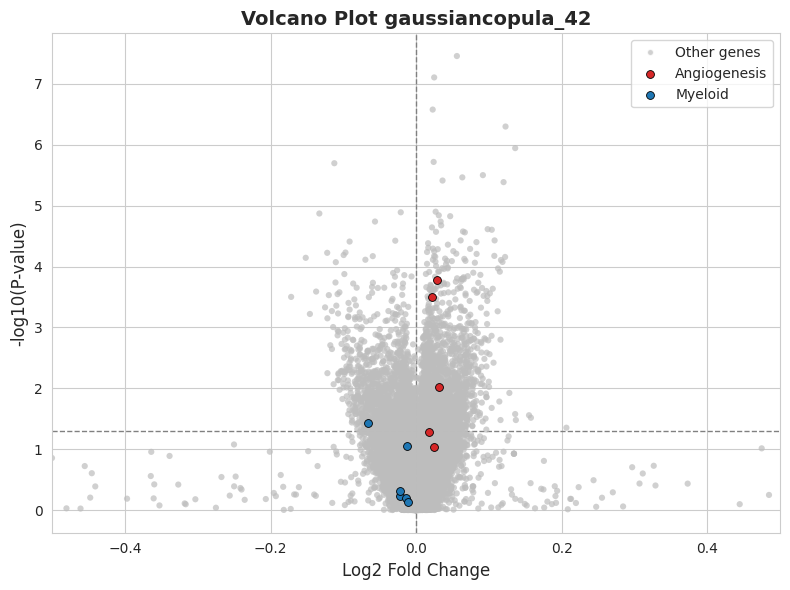

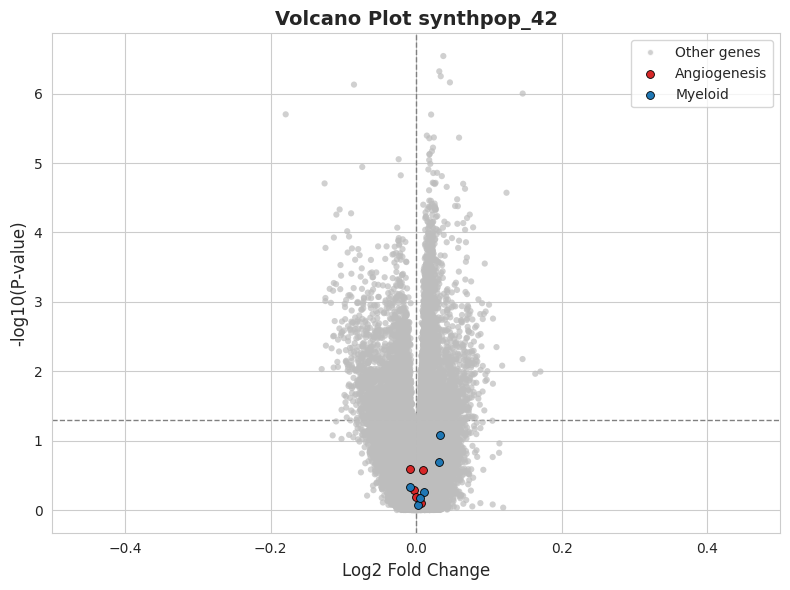

In [21]:
highlight_groups = {
    "Angiogenesis": Angio,
    "Myeloid": Myeloid,
    # "Javelin": Javelin,
    # "TIS":TIS
}
group_colors = {
    "Angiogenesis": "#d62728",  # red
    "Myeloid": "#1f77b4",       # blue
    # "Javelin": "#ff7f0e",       # orange
    # "TIS": "#2ca02c",           # green
}

for tool, degs_result in degs_results.items():
    fig = plot_volcano(degs_result, gene_col='Gene', log2fc_col='Log2FC', pval_col='P_value',
                       pval_thresh=0.05,highlight_groups=highlight_groups,
                        group_colors=group_colors,
                        xlim=(-0.5, 0.5),
                       annotate=False, title = f"Volcano Plot {tool}", savepath=f'DEG/VolcanoPlot_{tool}_PBRM1.png')
    plt.show()

In [6]:
from collections import Iterable
from typing import Dict, Optional, Tuple, Any, List

def _to_set(pathways: Iterable[Any], case_sensitive: bool = False) -> set:
    if pathways is None:
        return set()
    if not case_sensitive:
        return {str(x).strip().lower() for x in pathways if pd.notna(x)}
    else:
        return {str(x).strip() for x in pathways if pd.notna(x)}


def compute_jaccard_indices(
    original_pathways: Iterable[Any],
    synth_pathways_dict: Dict[str, Iterable[Any]],
    case_sensitive: bool = False,
) -> pd.DataFrame:
    """
    The Jaccard index is defined as:
        J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not isinstance(synth_pathways_dict, dict):
        raise ValueError("synth_pathways_dict must be a dict mapping dataset name -> iterable of pathways")

    A = _to_set(original_pathways, case_sensitive=case_sensitive)
    rows = []
    for ds_name, synth_paths in synth_pathways_dict.items():
        B = _to_set(synth_paths, case_sensitive=case_sensitive)
        inter = A.intersection(B)
        union = A.union(B)
        inter_size = len(inter)
        union_size = len(union)

        if union_size == 0:
            # both sets empty -> identical
            j = 1.0
        else:
            j = inter_size / union_size

        rows.append(
            {
                "Dataset": ds_name,
                "Original_count": len(A),
                "Synthetic_count": len(B),
                "Intersection": inter_size,
                "Union": union_size,
                "Jaccard": j,
            }
        )

    df = pd.DataFrame(rows, columns=["Dataset", "Original_count", "Synthetic_count", "Intersection", "Union", "Jaccard"])
    return df


def extract_significant_pathways(
    df: pd.DataFrame,
    term_col: str = "Term",
    adj_p_col: str = "P_value",
    threshold: float = 0.05,
) -> List[str]:
    if df is None or df.empty:
        return []
    if term_col not in df.columns or adj_p_col not in df.columns:
        return []
    df = df[df['Status']=='ok']
    sub = df[df[adj_p_col].astype(float) < float(threshold)].copy()
    # drop NA/empty terms and return list
    sub = sub[sub[term_col].notna()]
    return [str(x).strip() for x in sub[term_col].tolist()]

/tmp/ipykernel_294073/1018157330.py:1: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated since Python 3.3, and in 3.10 it will stop working
  from collections import Iterable


NameError: name 'pd' is not defined

In [5]:
orig_genes = extract_significant_pathways(degs_results["Origin"], term_col="Gene", adj_p_col="P_value", threshold=0.05)
synth_genes_dict = {k: extract_significant_pathways(v, term_col="Gene", adj_p_col="P_value", threshold=0.05)
                     for k, v in degs_results.items() if k != "Origin"}
jaccard_df = compute_jaccard_indices(orig_genes, synth_genes_dict)
jaccard_df.to_csv(f"DEG/JaccardIndex_{seed}_PBRM1.csv", index = False)
jaccard_df

NameError: name 'extract_significant_pathways' is not defined

In [4]:
from scipy.stats import spearmanr
DEGs_list = []
for name, df in degs_results.items():
    df["Dataset"] = name
    df['Rank_Score1'] = (df["Log2FC"])*(-np.log10(df['Q_value']))
    df['Rank_Score2'] = np.sign(df["Log2FC"])*(-np.log10(df['Q_value']))
    df['Rank_Score3'] = (df["Log2FC"])*(-np.log10(df['Q_value']))
    DEGs_list.append(df)
DEGs_df = pd.concat(DEGs_list, axis = 0)
pivot_df = DEGs_df.pivot_table(
    index="Gene",
    columns="Dataset",
    values="Rank_Score1"
)


origin_values = pivot_df["Origin"]

results = []

for dataset in pivot_df.columns:
    if dataset == "Origin":
        continue  # skip comparison with itself
    
    x = origin_values
    y = pivot_df[dataset]

    # Drop rows where either side is NaN
    valid = ~(x.isna() | y.isna())
    rho, pval = spearmanr(x[valid], y[valid])

    results.append({
        "Dataset": dataset,
        "Spearman_rho": rho,
        "p_value": pval,
        "n_terms_used": valid.sum()
    })

# Convert results to DataFrame
spearman_df = pd.DataFrame(results)
# spearman_df.to_csv(f"GSEA/Spearman_df{seed}.csv", index = False)
spearman_df

NameError: name 'degs_results' is not defined

In [49]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
def plot_jaccard_vs_spearman(
    jaccard_df: pd.DataFrame,
    spearman_df: pd.DataFrame,
    dataset_col: str = "Dataset",
    jaccard_col: str = "Jaccard",
    spearman_col: str = "Spearman_rho",
    size_col: Optional[str] = "Synthetic_count",
    annotate: bool = True,
    figsize: Tuple[float, float] = (8, 6),
    savepath: Optional[str] = None,
    title: Optional[str] = "Jaccard index vs Spearman rho",
) -> Tuple[plt.Figure, plt.Axes]:
    # Validate inputs
    if dataset_col not in jaccard_df.columns:
        raise ValueError(f"{dataset_col} not found in jaccard_df")
    if dataset_col not in spearman_df.columns:
        raise ValueError(f"{dataset_col} not found in spearman_df")
    if jaccard_col not in jaccard_df.columns:
        raise ValueError(f"{jaccard_col} not found in jaccard_df")
    if spearman_col not in spearman_df.columns:
        raise ValueError(f"{spearman_col} not found in spearman_df")

    # Merge on dataset
    df = pd.merge(
        spearman_df,
        jaccard_df,
        on=dataset_col,
        how="outer",
        suffixes=("_spearman", "_jaccard"),
    )

    # Prepare columns
    df = df.rename(columns={jaccard_col: "Jaccard", spearman_col: "Spearman_rho"})
    # If user requested size_col but it has different name in jaccard_df, try to keep as-is
    if size_col is not None and size_col not in df.columns:
        # fall back to n_terms_used or Synthetic_count if available
        if "n_terms_used" in df.columns:
            size_col = "n_terms_used"
        elif "Synthetic_count" in df.columns:
            size_col = "Synthetic_count"
        else:
            size_col = None

    # Drop rows that do not have both metrics (can't plot)
    plot_df = df.loc[df["Jaccard"].notna() & df["Spearman_rho"].notna()].copy()

    # If no rows to plot, create empty figure with message
    if plot_df.shape[0] == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No datasets with both Jaccard and Spearman available", ha="center", va="center")
        ax.axis("off")
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        return fig, ax

    # # Compute Spearman correlation between Jaccard and Spearman_rho (on available rows)
    # rho, pval = spearmanr(plot_df["Jaccard"], plot_df["Spearman_rho"], nan_policy="omit")

    # Determine point sizes
    if size_col is not None:
        # scale sizes to a reasonable range
        raw_sizes = plot_df[size_col].fillna(0).astype(float)
        # map zero -> small, others scaled
        min_size = 50
        max_size = 450
        if raw_sizes.max() == raw_sizes.min():
            sizes = np.full(len(raw_sizes), (min_size + max_size) / 2.0)
        else:
            sizes = min_size + (raw_sizes - raw_sizes.min()) / (raw_sizes.max() - raw_sizes.min()) * (max_size - min_size)
    else:
        sizes = 120

    # Create plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        x=plot_df["Jaccard"],
        y=plot_df["Spearman_rho"],
        s=sizes,
        c="tab:blue",
        edgecolor="k",
        alpha=0.85,
        linewidth=0.6,
        zorder=3,
    )


    # Annotate each point with dataset name if requested (with small offset)
    if annotate:
        for _, row in plot_df.iterrows():
            dx = 0.005 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # small fraction of x-range
            dy = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])  # small fraction of y-range
            ax.text(
                row["Jaccard"] + dx,
                row["Spearman_rho"] + dy,
                str(row[dataset_col]),
                fontsize=8,
                verticalalignment="bottom",
                horizontalalignment="left",
            )

    # Labels, title, legend, annotation for correlation
    ax.set_xlabel("Jaccard index", fontsize=11)
    ax.set_ylabel("Spearman rho", fontsize=11)
    ax.set_title(title, fontsize=12)



    # A grid and tight layout
    ax.grid(alpha=0.4, linestyle="--")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax

In [53]:
jaccard_df

,Dataset,Original_count,Synthetic_count,Intersection,Union,Jaccard
0,avatarsk5_42,4101,2975,898,6178,0.145354
1,avatarsk10_42,4101,4621,1084,7638,0.141922
2,ctgan_42,4101,1533,192,5442,0.035281
3,gaussiancopula_42,4101,3501,1614,5988,0.269539
4,synthpop_42,4101,5719,896,8924,0.100403


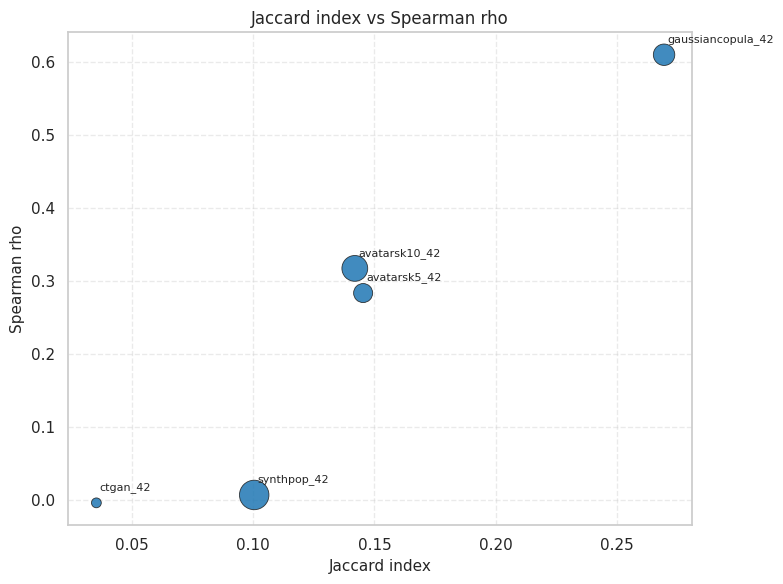

In [52]:
fig, ax = plot_jaccard_vs_spearman(jaccard_df, spearman_df, 
                                   size_col="Synthetic_count", annotate=True, savepath=None)
plt.show()

/tmp/ipykernel_1953212/2493105114.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Overlap_ratio", y="Dataset", data=df, palette="viridis", ax=ax)


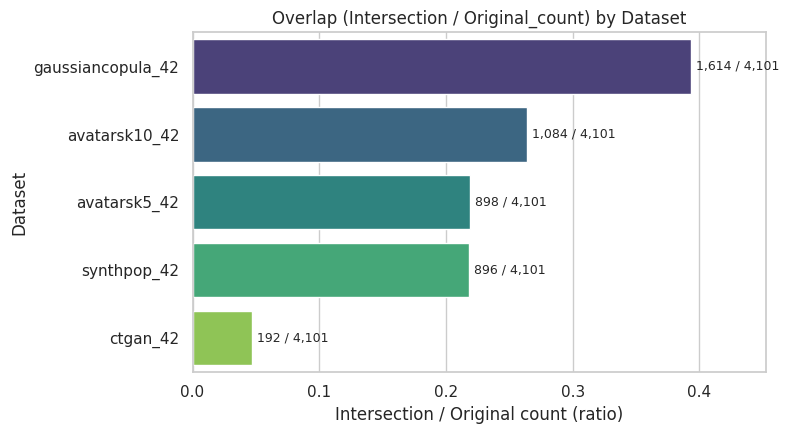

In [59]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Replace this CSV block with your existing DataFrame if you already have `df`
csv = """Dataset\tOriginal_count\tSynthetic_count\tIntersection\tUnion\tJaccard
avatarsk5_42\t4101\t2975\t898\t6178\t0.145354
avatarsk10_42\t4101\t4621\t1084\t7638\t0.141922
ctgan_42\t4101\t1533\t192\t5442\t0.035281
gaussiancopula_42\t4101\t3501\t1614\t5988\t0.269539
synthpop_42\t4101\t5719\t896\t8924\t0.100403
"""
df = pd.read_csv(io.StringIO(csv), sep="\t")

# Ensure numeric
df["Original_count"] = pd.to_numeric(df["Original_count"], errors="coerce")
df["Intersection"] = pd.to_numeric(df["Intersection"], errors="coerce")

# Compute ratio for ordering (optional)
df["Overlap_ratio"] = df["Intersection"] / df["Original_count"]
df = df.sort_values("Overlap_ratio", ascending=False).reset_index(drop=True)

# Plot horizontal barplot
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x="Overlap_ratio", y="Dataset", data=df, palette="viridis", ax=ax)

# Annotate with "Intersection / Original" (e.g., "1614 / 4101")
xmax = df["Overlap_ratio"].max(skipna=True)
offset = (xmax * 0.01) if (xmax and not np.isnan(xmax)) else 0.01

for patch, (_, row) in zip(ax.patches, df.iterrows()):
    width = patch.get_width()
    inter = row["Intersection"]
    orig = row["Original_count"]
    if pd.isna(inter) or pd.isna(orig):
        label = "n/a"
    else:
        # Format as integers
        label = f"{int(inter):,} / {int(orig):,}"
    ax.text(width + offset, 
            patch.get_y() + patch.get_height() / 2,
            label,
            va="center", fontsize=9)

ax.set_xlabel("Intersection / Original count (ratio)")
ax.set_xlim(0, (xmax * 1.15) if (xmax and not np.isnan(xmax)) else 1)
ax.set_title("Overlap (Intersection / Original_count) by Dataset")
plt.tight_layout()
plt.show()

In [77]:
# -*- coding: utf-8 -*-
"""
Draw a fixed-list pathway scatter grid from ssGSEA comparison results, with:
- Unified x-axis range across panels
- Bubble color by p-value bin (not gradient)
- **Fixed bubble size** (bubble size does NOT encode p-value or any data variable)

Returns:
    tuple: (matplotlib.figure.Figure, pandas.DataFrame)
        - Figure: The created matplotlib Figure object.
        - DataFrame: The concatenated DataFrame used for plotting (columns include
          ['Dataset','Term','adj_pvalues','Diff_NES','-log10(qvalue)','NES_diff','y', 'pvalue_bin']).
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Any, Tuple
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_pathway_fixed_list(
    ssGSEA_comparison: Dict[str, pd.DataFrame],
    ref_pathway_list: List[str] = [
        'Estrogen Response Late', 'Estrogen Response Early', 'Spermatogenesis',
        'Allograft Rejection', 'IL-6/JAK/STAT3 Signaling','Apoptosis','UV Response Up',
        'Pancreas Beta Cells','Epithelial Mesenchymal Transition'
    ],
    highlight_pathways: List[str] = ['IL-6/JAK/STAT3 Signaling'],
    origin_name: str = "Origin",
    adj_p_threshold: float = 0.25,
    pval_bin_colors: List[str] = ["#d62728", "#ff7f0e", "#1f77b4", "#cccccc"],  # red, orange, blue, gray
    fig_width_min: float = 14.0,
    bubble_size: float = 170,   # Fixed size for all bubbles
    show: bool = True,
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
) -> Tuple[plt.Figure, pd.DataFrame]:
    if not ssGSEA_comparison:
        raise ValueError("ssGSEA_comparison must not be empty.")
    if not ref_pathway_list:
        raise ValueError("ref_pathway_list must not be empty.")

    datasets = list(ssGSEA_comparison.keys())

    # Prepare filtered data and global scales
    all_data_to_plot = []
    global_nes_values = []

    for ds_name in datasets:
        if ds_name not in ssGSEA_comparison:
            continue
        df_ds = ssGSEA_comparison[ds_name].copy()

        if "Term" not in df_ds.columns or "adj_pvalues" not in df_ds.columns or "Diff_NES" not in df_ds.columns:
            continue

        sub_df = df_ds[df_ds["Term"].isin(ref_pathway_list)].copy()
        if sub_df.empty:
            continue

        sub_df["Dataset"] = ds_name
        sub_df["-log10(qvalue)"] = -np.log10(sub_df["adj_pvalues"].clip(lower=np.nextafter(0, 1)))
        sub_df["NES_diff"] = sub_df["Diff_NES"].fillna(0)

        global_nes_values.extend(sub_df["NES_diff"].tolist())
        all_data_to_plot.append(sub_df)

    if not all_data_to_plot:
        fig = plt.figure(figsize=(8, 3))
        ax = fig.add_subplot(111)
        ax.text(0.5, 0.5, "No data to plot for the provided reference pathways.", ha="center", va="center", fontsize=12)
        ax.axis("off")
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        if show:
            plt.show()
        return (fig, pd.DataFrame([])) if return_dataframe else (fig, None)

    df_plot = pd.concat(all_data_to_plot, ignore_index=True)

    # --- Unified axes: use global NES range across all datasets ---
    max_abs_nes = np.nanmax(np.abs(global_nes_values))
    if max_abs_nes == 0 or np.isnan(max_abs_nes):
        max_abs_nes = 1.0

    # --- p-value bins and colors ---
    bins = [0, 0.01, 0.05, 0.25, 1.01]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    color_map = dict(zip(bin_labels, pval_bin_colors))
    df_plot["pvalue_bin"] = pd.cut(df_plot["adj_pvalues"], bins=bins, labels=bin_labels, include_lowest=True, right=False)

    # Y ordering
    origin_df = df_plot[df_plot["Dataset"] == origin_name].copy()
    if not origin_df.empty:
        origin_df = origin_df.sort_values(by="adj_pvalues", ascending=True)
        sorted_pathways = origin_df["Term"].tolist()
        for p in ref_pathway_list:
            if p not in sorted_pathways:
                sorted_pathways.append(p)
        sorted_pathways = [p for p in sorted_pathways if p in ref_pathway_list]
    else:
        sorted_pathways = [p for p in ref_pathway_list if p in df_plot["Term"].unique()]
        if not sorted_pathways:
            sorted_pathways = sorted(list(df_plot["Term"].unique()))
    y_labels = sorted_pathways[::-1]
    y_pos = np.arange(len(y_labels))
    mapping = {p: idx for idx, p in enumerate(y_labels)}

    N_COLS = len(datasets)
    FIG_WIDTH = max(3.5 * N_COLS + 2, fig_width_min)
    FIG_HEIGHT = max(0.6 * len(y_labels) + 3, 7)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=N_COLS,
        figsize=(FIG_WIDTH, FIG_HEIGHT),
        sharey=True,
        sharex=True,
    )

    if N_COLS == 1:
        axes_list = [axes]
    else:
        axes_list = list(np.array(axes).flatten())

    plt.subplots_adjust(left=0.25, right=0.90, top=0.85, bottom=0.08, wspace=0.15)

    for i, ds in enumerate(datasets):
        ax = axes_list[i]
        sub = df_plot[df_plot["Dataset"] == ds].copy()
        sub["y"] = sub["Term"].map(mapping)

        if sub.empty or sub["y"].isna().all():
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10, color="grey", transform=ax.transAxes)
            ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
            ax.set_xticks([])
            ax.set_title(ds, fontsize=10, fontweight="bold", pad=10)
            ax.tick_params(left=False, labelleft=False)
            ax.grid(axis="y", linestyle="--", alpha=0.4)
            continue

        bubble_colors = sub["pvalue_bin"].map(color_map).fillna("#cccccc")

        ax.scatter(
            x=sub["NES_diff"],
            y=sub["y"],
            s=bubble_size,
            c=bubble_colors,
            edgecolor="k",
            linewidths=0.4,
            alpha=0.9,
        )

        ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.5, zorder=-1)
        ax.set_xlim(-max_abs_nes * 1.05, max_abs_nes * 1.05)
        ax.set_xlabel("NES_change (MUT - WT)", fontsize=9, labelpad=5)

        ax.set_yticks(y_pos)
        ax.set_ylim(len(y_labels) - 0.5 + 0.5, -0.5 - 0.5)
        ax.invert_yaxis()
        ax.set_title(ds, fontsize=10, fontweight="bold", pad=10)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

        if i == 0:
            ax.set_yticklabels(y_labels, fontsize=9)
            ax.tick_params(axis="y", which="major", pad=5)
            for label in ax.get_yticklabels():
                pathway_name = label.get_text()
                if pathway_name in highlight_pathways:
                    label.set_color("red")
                    label.set_fontweight("bold")
                else:
                    label.set_color("black")
        else:
            ax.tick_params(left=False, labelleft=False)

    # Remove unused axes
    if len(axes_list) > N_COLS:
        for j in range(N_COLS, len(axes_list)):
            fig.delaxes(axes_list[j])

    # Add manual legend for p-value bins
    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(color=color_map[l], label=l)
        for l in bin_labels
    ]
    axes_list[-1].legend(handles=legend_patches, title="Adjusted p-value", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=9, frameon=False)

    plt.tight_layout(rect=[0, 0.03, 0.90, 0.98])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    df_plot["y"] = df_plot["Term"].map(mapping)

    return (fig, df_plot) if return_dataframe else (fig, None)

In [91]:
from typing import List, Optional, Any, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as mpatches

def plot_pathway_df(
    df: pd.DataFrame,
    ref_pathway_list: List[str],
    x_col: str = "NES_diff",
    y_col: str = "Term",
    p_value_col: str = "p_values",
    color_col: Optional[str] = None,   # ignored when using p-value bins
    highlight_pathways: Optional[List[str]] = None,
    order_by: Optional[str] = None,
    p_threshold: float = 0.05,         # kept but not used for color now
    fig_width_min: float = 10.0,
    marker_size: float = 100.0,        # fixed marker size (no scaling)
    show: bool = True,
    title: str = "Pathway bubble plot",
    save_path: Optional[str] = None,
    return_dataframe: bool = True,
    eps: float = 1e-9,                 # small epsilon added to p-values when needed
    xlim: Tuple[float, float] = (-3.0, 3.0),  # fixed x-axis range
    pval_bin_colors: List[str] = None,
) -> Tuple[plt.Figure, Optional[pd.DataFrame]]:

    """
    Plot a bubble plot for pathways with:
    - fixed x-axis range (default -3 to 3, configurable via `xlim`)
    - discrete bubble colors based on p-value bins:
        p < 0.01          -> first color
        0.01 ≤ p < 0.05   -> second color
        0.05 ≤ p < 0.25   -> third color
        p ≥ 0.25          -> fourth color
    """

    if df is None or df.empty:
        raise ValueError("Input DataFrame `df` is empty or None.")
    if not ref_pathway_list:
        raise ValueError("`ref_pathway_list` must not be empty.")
    if y_col not in df.columns:
        raise ValueError(f"y_col '{y_col}' not found in DataFrame columns.")
    if p_value_col not in df.columns:
        raise ValueError(f"p_value_col '{p_value_col}' not found in DataFrame columns.")

    # default colors if not provided
    if pval_bin_colors is None:
        # p<0.01, 0.01≤p<0.05, 0.05≤p<0.25, p≥0.25
        pval_bin_colors = ["#d62728", "#ff7f0e", "#1f77b4", "#7f7f7f"]

    df = df.copy()

    # Coerce numeric columns safely
    df[p_value_col] = pd.to_numeric(df[p_value_col], errors="coerce")
    if x_col in df.columns:
        df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    else:
        df[x_col] = np.nan

    # Filter to reference pathways (ensure string matching)
    df[y_col] = df[y_col].astype(str)
    df_plot = df[df[y_col].isin([str(x) for x in ref_pathway_list])].copy()

    if df_plot.empty:
        fig = plt.figure(figsize=(8, 3))
        ax = fig.add_subplot(111)
        ax.text(0.5, 0.5, "No data to plot for the provided reference pathways.",
                ha="center", va="center", fontsize=12)
        ax.axis("off")
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        if show:
            plt.show()
        return (fig, pd.DataFrame([])) if return_dataframe else (fig, None)

    # --- Assign p-value bins and colors ---
    bins = [0, 0.01, 0.05, 0.25, 1.0 + eps]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    df_plot["pvalue_bin"] = pd.cut(
        df_plot[p_value_col],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )
    color_map = dict(zip(bin_labels, pval_bin_colors))

    # IMPORTANT FIX: convert to object/str before fillna("#cccccc")
    bubble_colors = df_plot["pvalue_bin"].map(color_map).astype(object)
    bubble_colors = bubble_colors.fillna("#cccccc")

    # --- Determine ordering of y labels ---
    present_pathways = list(df_plot[y_col].unique())
    if order_by and order_by in df_plot.columns:
        order_series = pd.to_numeric(df_plot[order_by], errors="coerce")
        order_df = df_plot[[y_col, order_by]].copy()
        order_df[order_by] = order_series
        order_df = order_df.dropna(subset=[order_by]).drop_duplicates(subset=[y_col])
        order_df = order_df.sort_values(by=order_by, ascending=True)
        sorted_pathways = [p for p in order_df[y_col].tolist() if p in ref_pathway_list]
        for p in ref_pathway_list:
            if p not in sorted_pathways and p in present_pathways:
                sorted_pathways.append(p)
    else:
        sorted_pathways = [p for p in ref_pathway_list if p in present_pathways]

    if not sorted_pathways:
        sorted_pathways = sorted(present_pathways)

    # Final y labels (reverse for top-to-bottom plotting)
    y_labels = [str(p) for p in sorted_pathways[::-1]]
    mapping = {p: idx for idx, p in enumerate(y_labels)}
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    # Extract plotting arrays
    x_plot = pd.to_numeric(df_plot[x_col], errors="coerce").values
    y_plot = df_plot["y"].values

    # Fixed marker size
    size_norm = np.full(shape=len(df_plot), fill_value=float(marker_size))

    # --- Create figure ---
    FIG_WIDTH = max(fig_width_min, 10.0)
    FIG_HEIGHT = max(0.6 * len(y_labels) + 2, 6)
    fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))

    sc = ax.scatter(
        x=x_plot,
        y=y_plot,
        s=size_norm,
        c=bubble_colors,
        edgecolor="k",
        linewidths=0.4,
        alpha=0.9,
        zorder=3,
    )

    # Fixed x-axis range
    ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
    ax.set_xlim(xlim[0], xlim[1])

    # y-ticks and labels
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_ylim(len(y_labels) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel(x_col, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")

    # Highlight pathways on y-axis labels
    if highlight_pathways is None:
        highlight_pathways = []
    highlight_set = set(str(x) for x in highlight_pathways)
    for label in ax.get_yticklabels():
        pathway_name = label.get_text()
        if pathway_name in highlight_set:
            label.set_color("red")
            label.set_fontweight("bold")
        else:
            label.set_color("black")

    # --- Discrete legend for p-value bins instead of colorbar ---
    legend_patches = [
        mpatches.Patch(color=color_map[l], label=l)
        for l in bin_labels
    ]
    ax.legend(
        handles=legend_patches,
        title="p-value",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
        title_fontsize=9,
        frameon=False,
    )

    # Layout
    plt.subplots_adjust(left=0.30, right=0.80, top=0.95, bottom=0.08)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    if show:
        plt.show()

    # attach mapping y positions to df_plot for downstream usage
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    return (fig, df_plot) if return_dataframe else (fig, None)

In [93]:
orig_paths

['HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
 'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
 'HALLMARK_FATTY_ACID_METABOLISM',
 'HALLMARK_COAGULATION',
 'HALLMARK_MTORC1_SIGNALING',
 'HALLMARK_COMPLEMENT',
 'HALLMARK_INFLAMMATORY_RESPONSE',
 'HALLMARK_IL6_JAK_STAT3_SIGNALING',
 'HALLMARK_UNFOLDED_PROTEIN_RESPONSE',
 'HALLMARK_HYPOXIA',
 'HALLMARK_ADIPOGENESIS',
 'HALLMARK_GLYCOLYSIS',
 'HALLMARK_PEROXISOME',
 'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
 'HALLMARK_KRAS_SIGNALING_UP',
 'HALLMARK_DNA_REPAIR',
 'HALLMARK_P53_PATHWAY',
 'HALLMARK_ALLOGRAFT_REJECTION',
 'HALLMARK_ANGIOGENESIS',
 'HALLMARK_APOPTOSIS',
 'HALLMARK_ESTROGEN_RESPONSE_LATE']

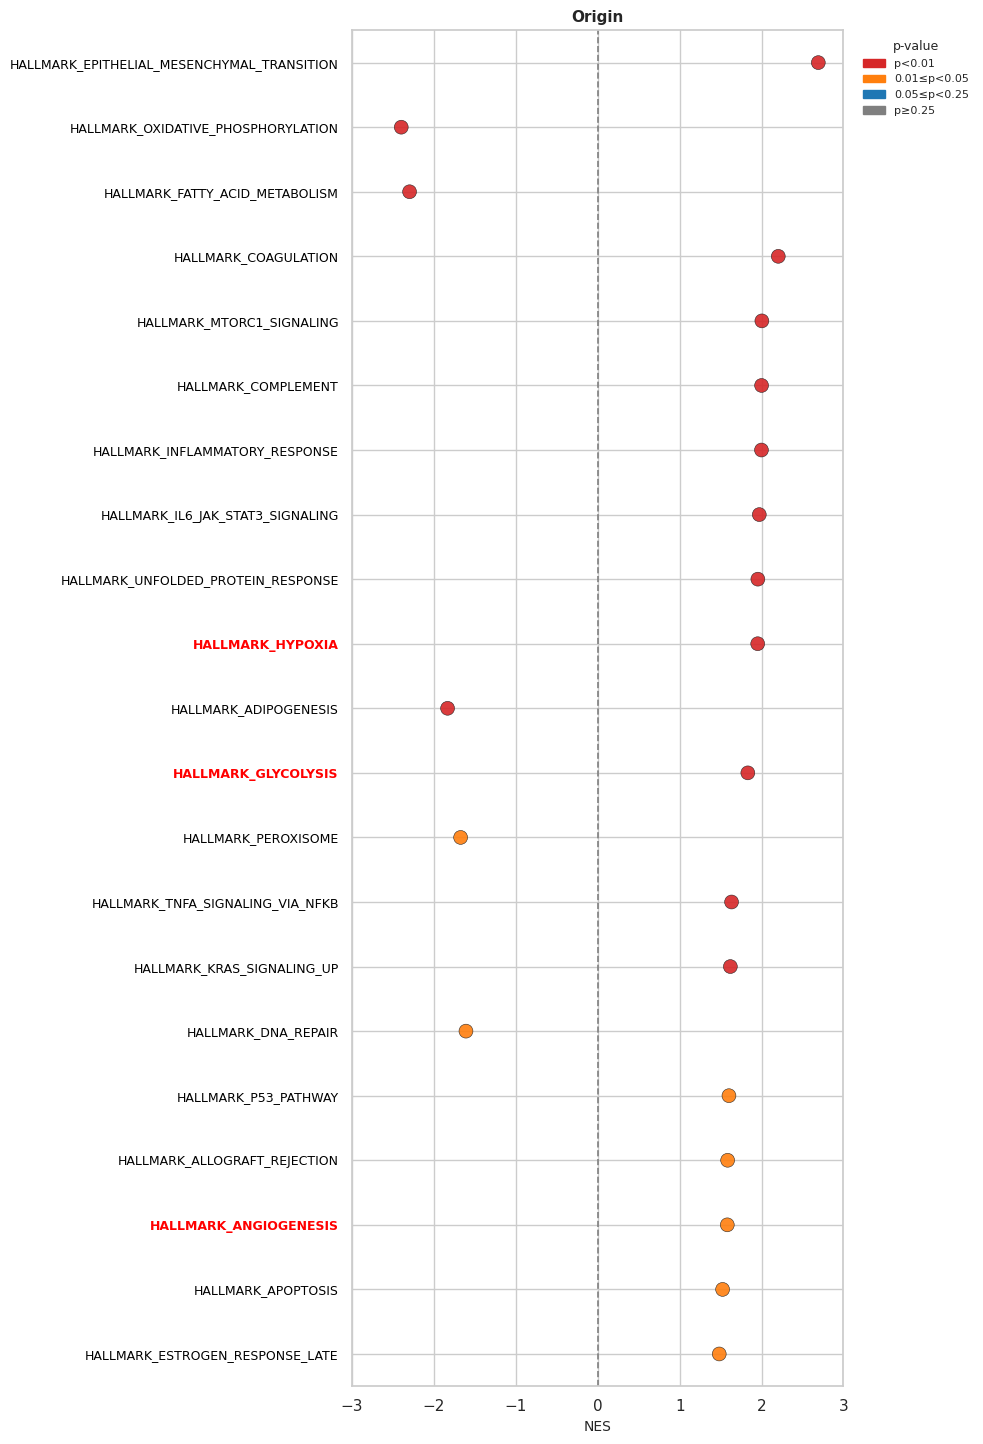

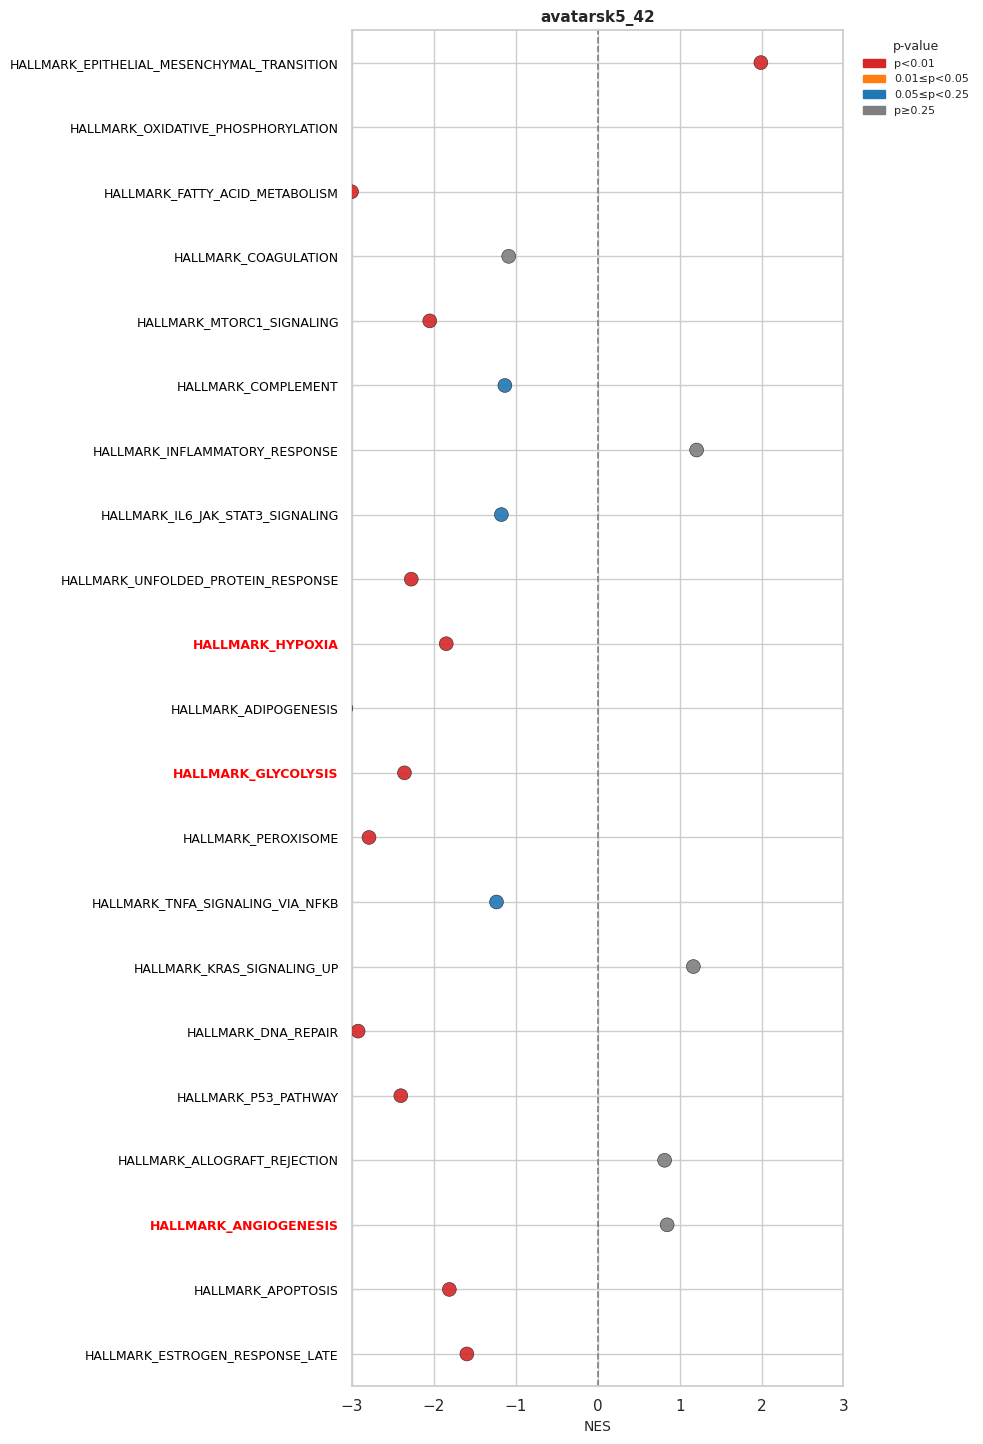

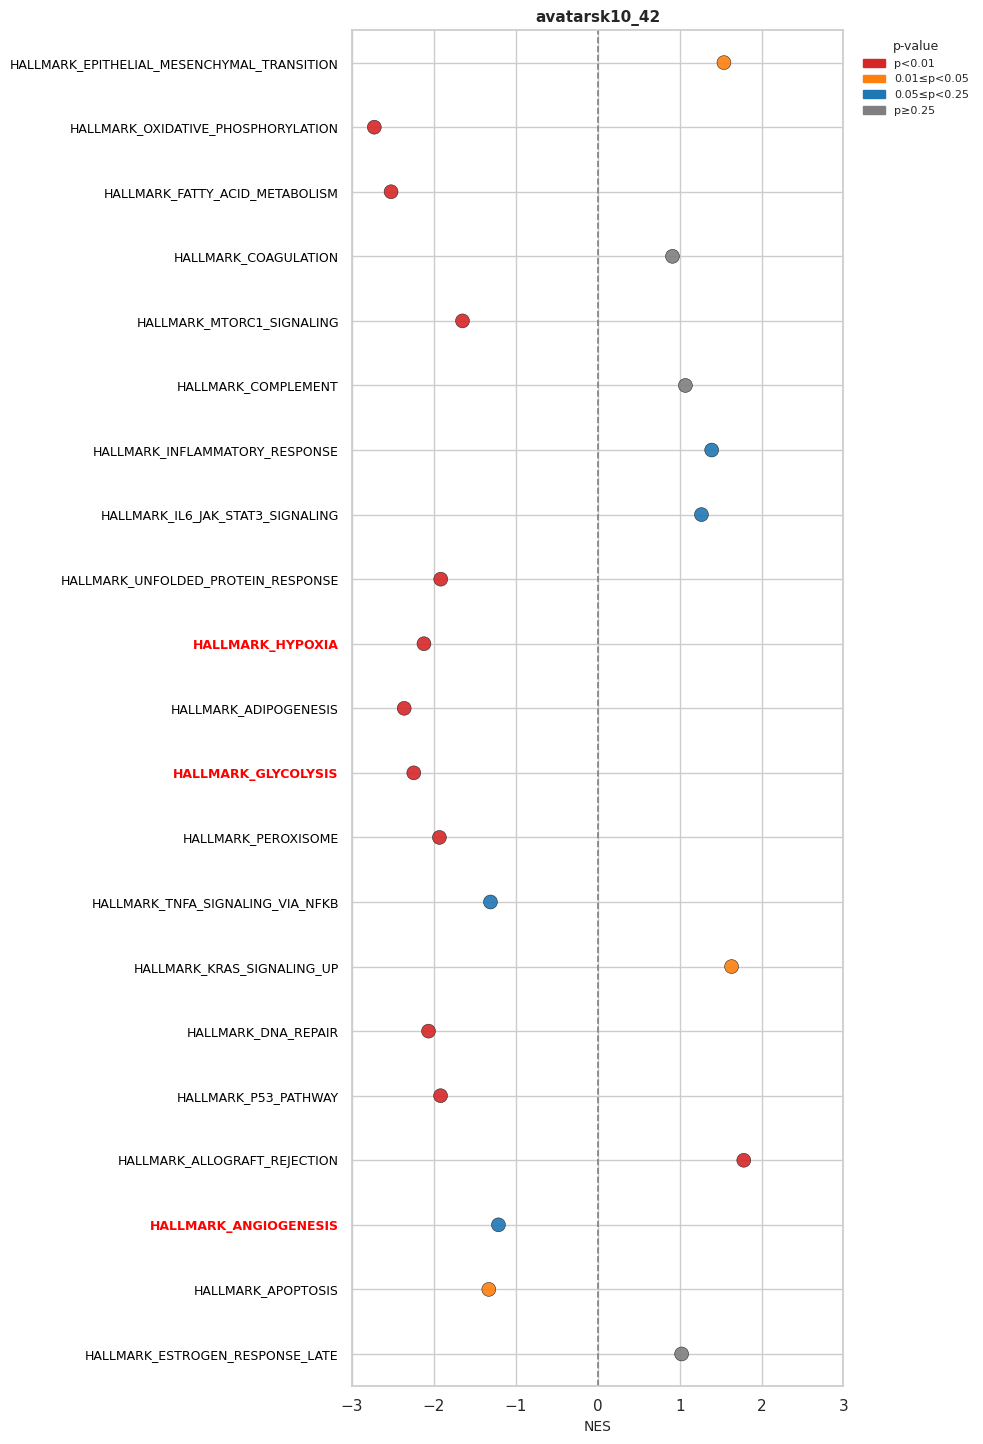

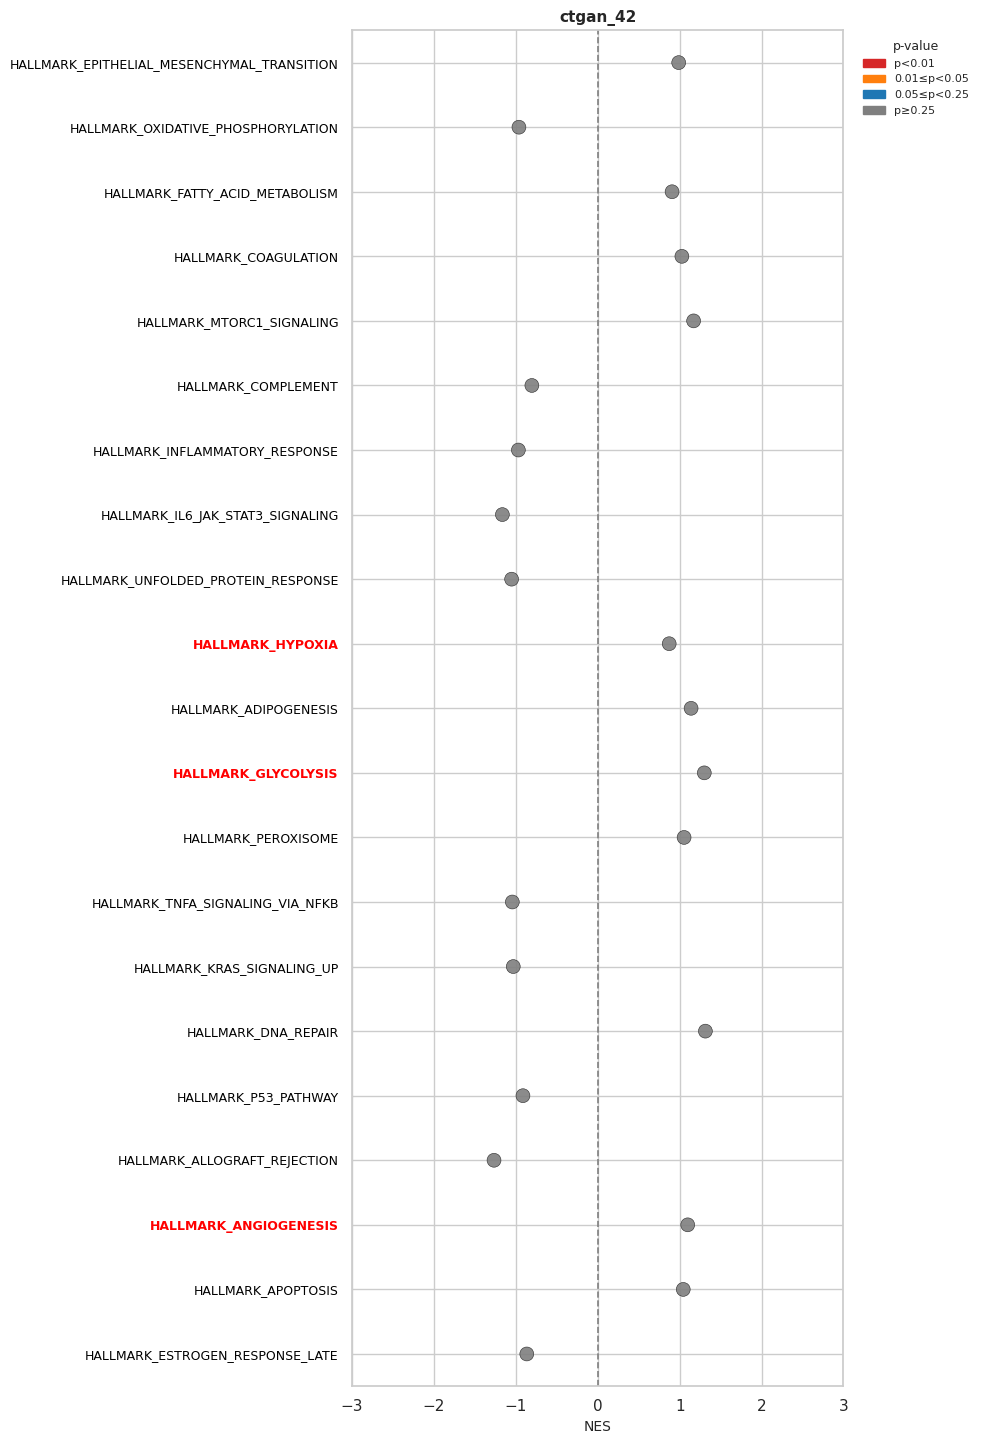

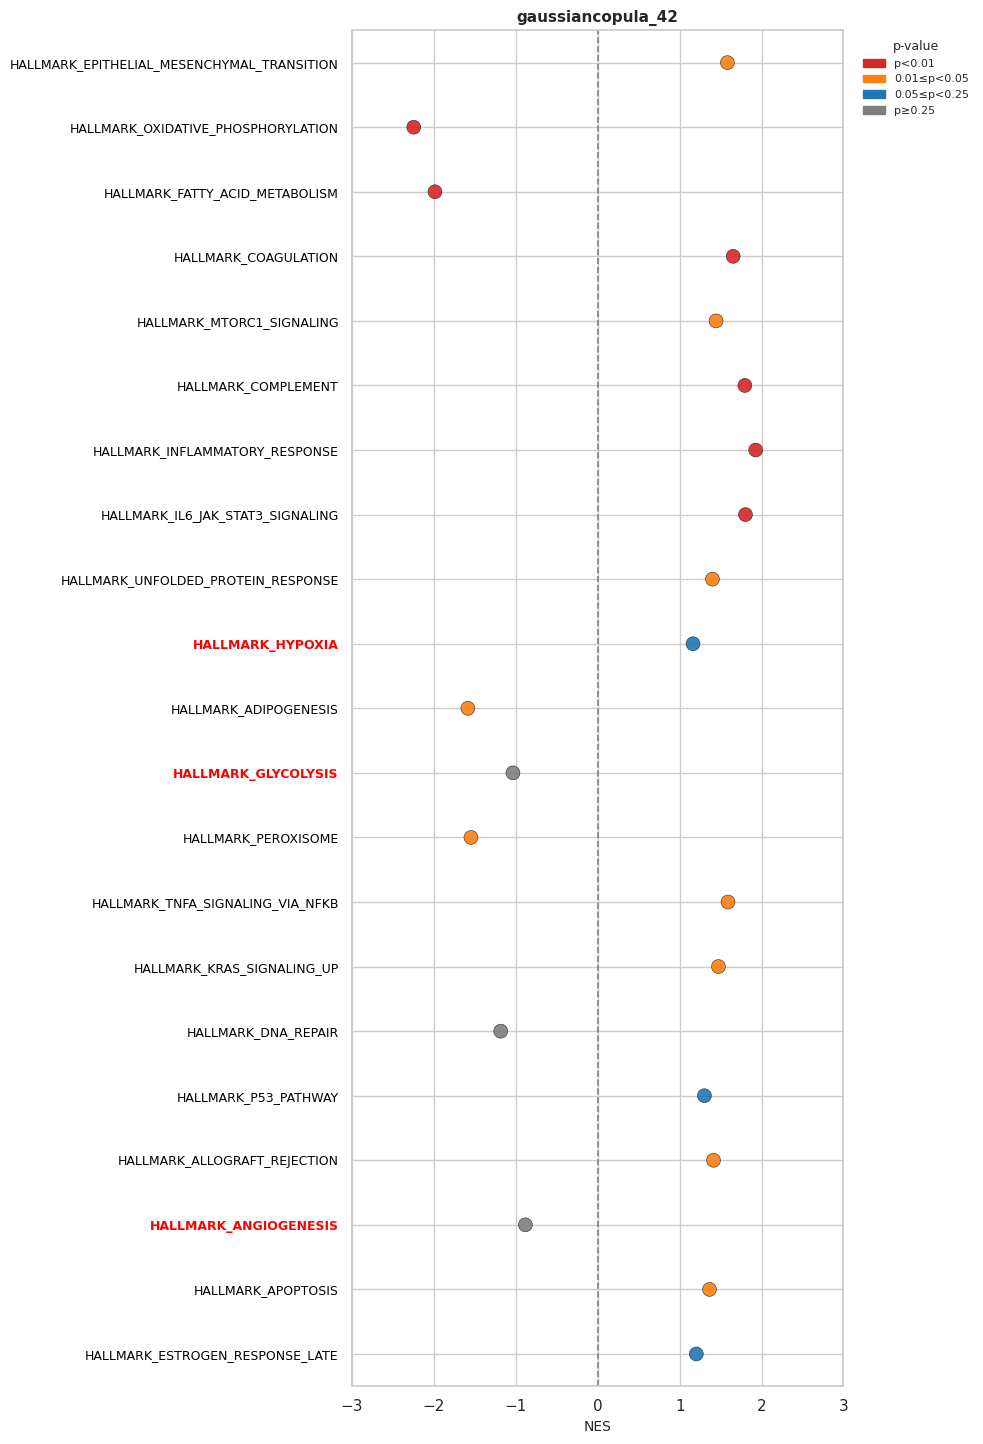

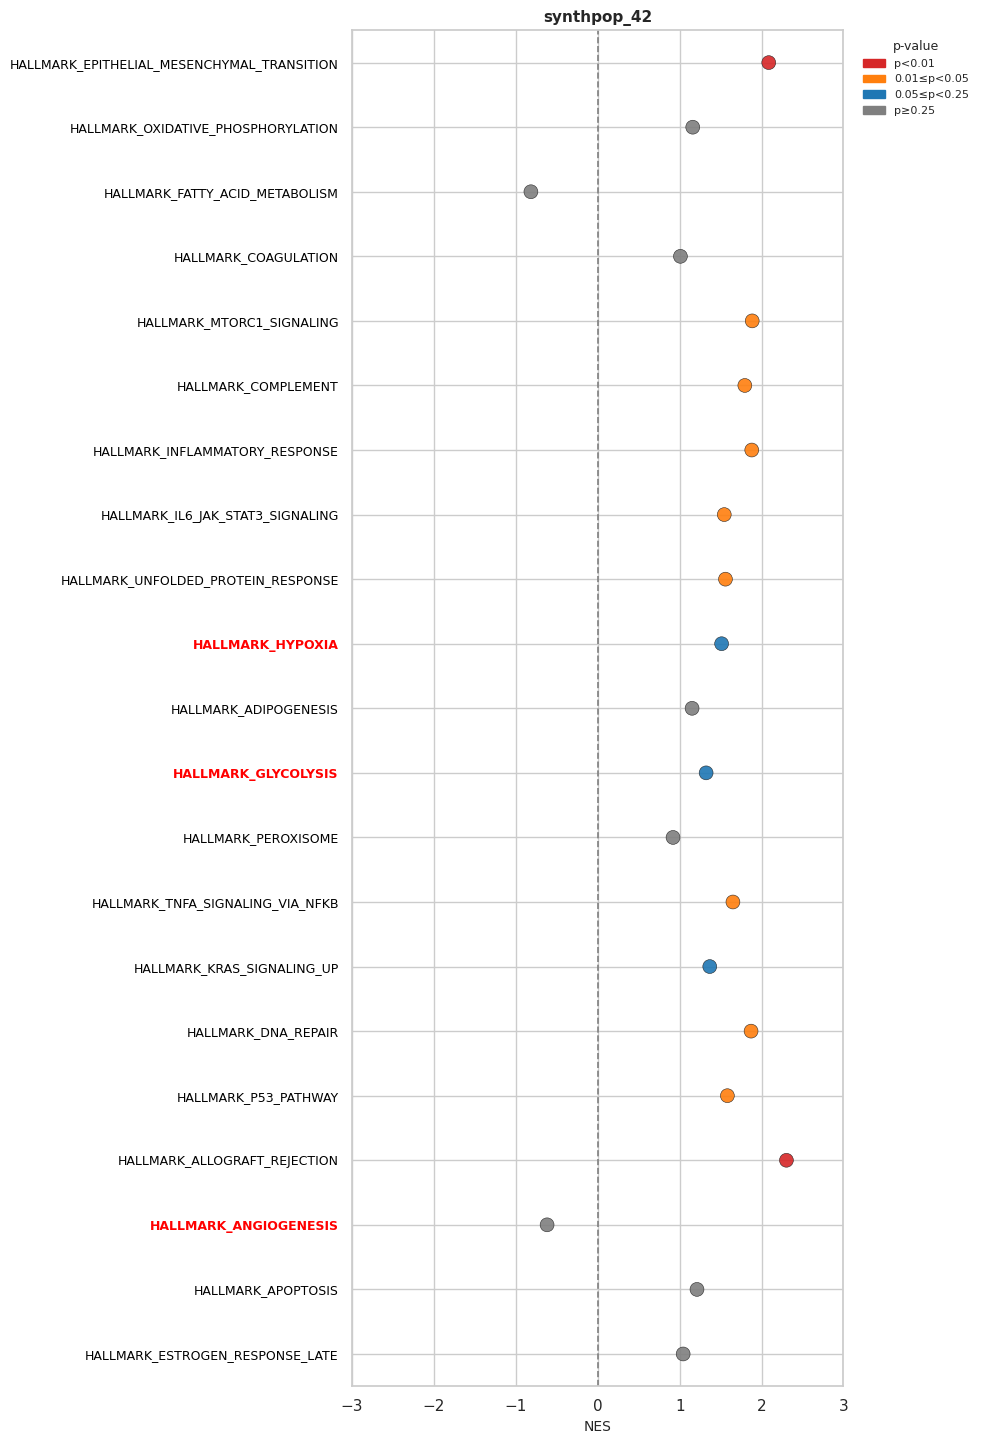

In [95]:
# Example usage:
highligt_paths = ['HALLMARK_HYPOXIA','HALLMARK_ANGIOGENESIS','HALLMARK_GLYCOLYSIS']
for tool, GSEA_df in GSEA_overall.items():
    fig, df_out = plot_pathway_df(GSEA_df, ref_pathway_list=orig_paths, xlim=(-3, 3), x_col="NES", y_col="Term",
                                  p_value_col="FDR q-val", highlight_pathways=highligt_paths, title = f"{tool}",
                                    # save_path =f"GSEA/BubblePlot_{tool}_{seed}.png",
                                   color_col=None, order_by=None)

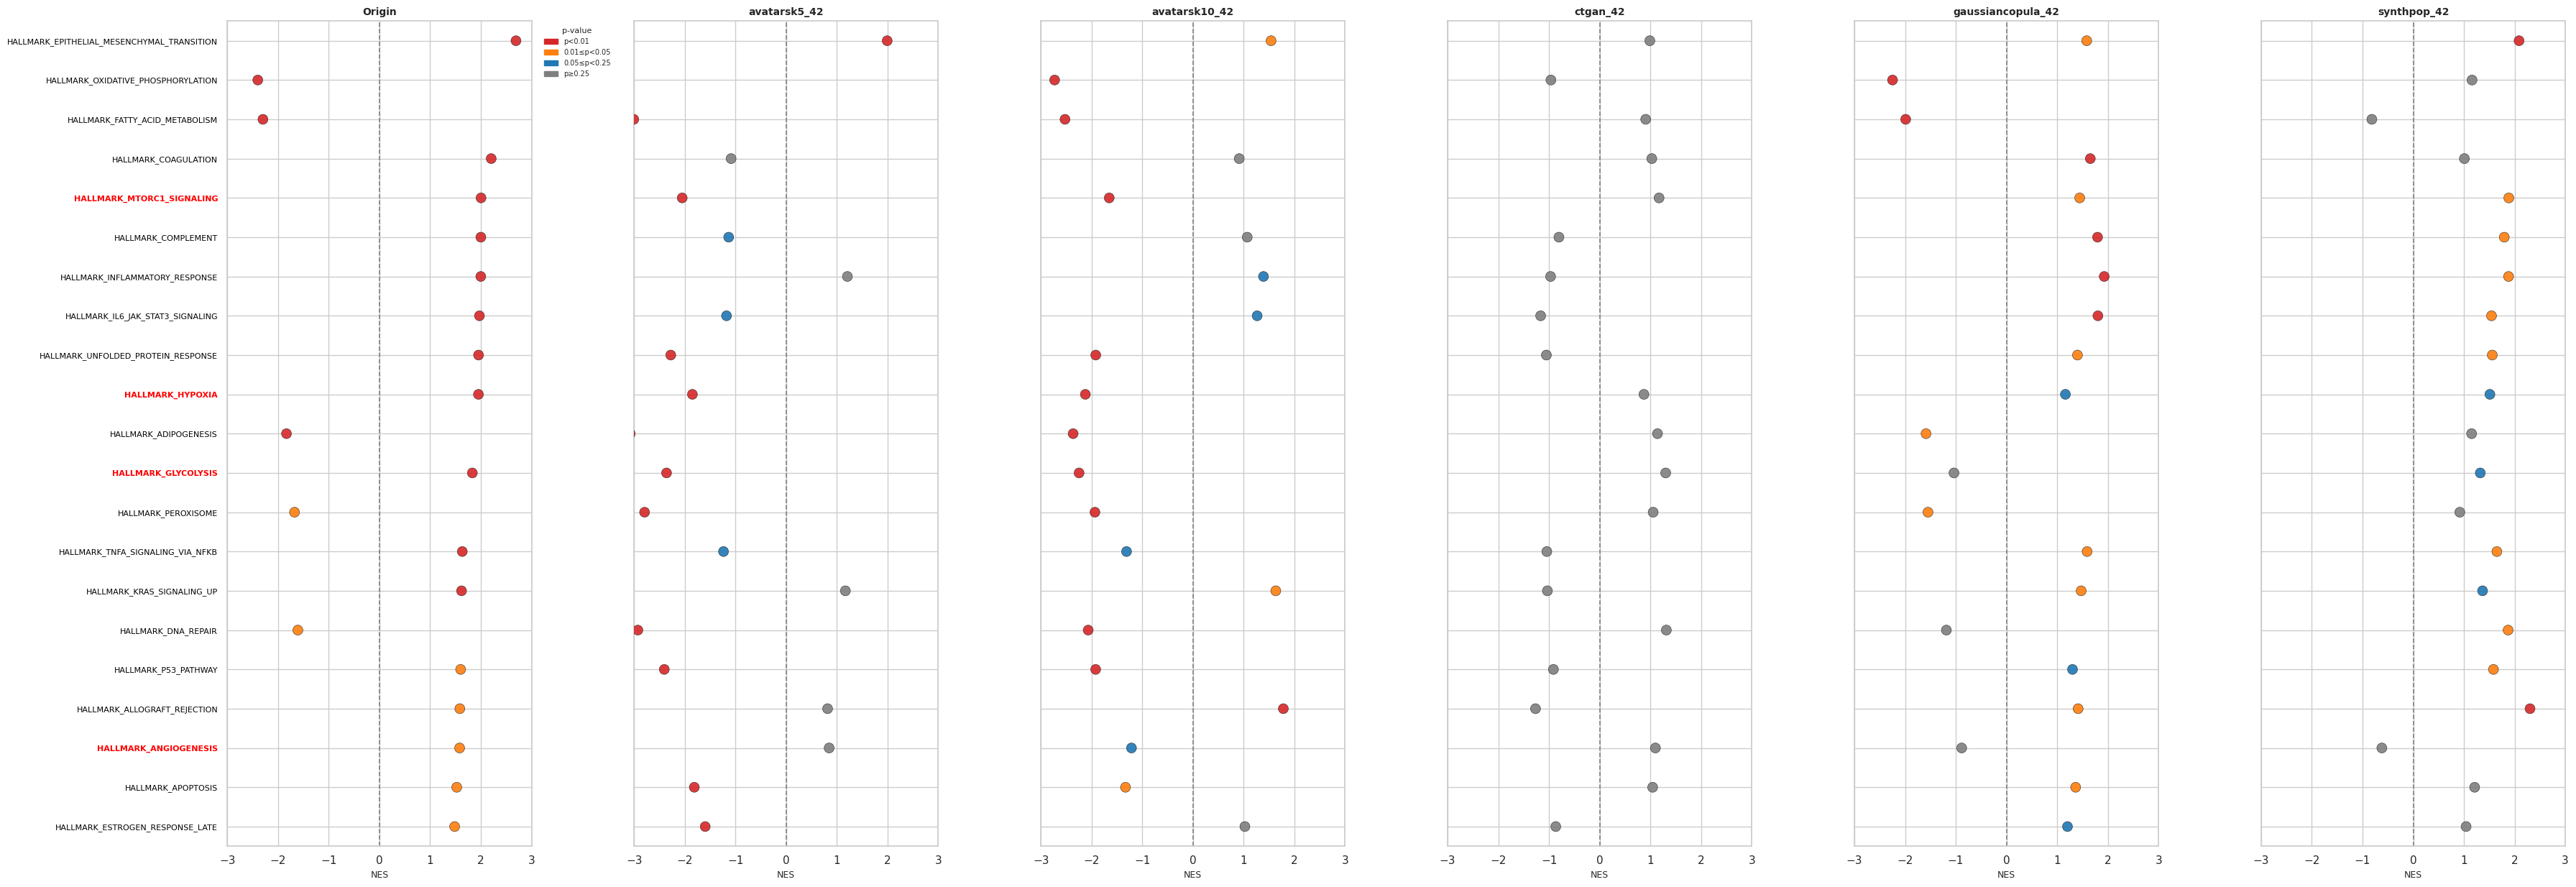

In [107]:
# Example usage for grid
from typing import List, Optional, Any, Tuple, Dict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_pathway_df_ax(
    ax: plt.Axes,
    df: pd.DataFrame,
    ref_pathway_list: List[str],
    x_col: str = "NES_diff",
    y_col: str = "Term",
    p_value_col: str = "p_values",
    highlight_pathways: Optional[List[str]] = None,
    order_by: Optional[str] = None,
    fig_xlim: Tuple[float, float] = (-3.0, 3.0),
    marker_size: float = 100.0,
    eps: float = 1e-9,
    pval_bin_colors: List[str] = None,
    title: str = "",
    add_legend: bool = False,
) -> pd.DataFrame:
    """
    Draw a pathway bubble plot for a single dataset into a given Axes.

    Colors are discrete p-value bins:
        p < 0.01          -> first color
        0.01 ≤ p < 0.05   -> second color
        0.05 ≤ p < 0.25   -> third color
        p ≥ 0.25          -> fourth color
    """

    if df is None or df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10)
        ax.axis("off")
        return pd.DataFrame([])

    if not ref_pathway_list:
        raise ValueError("`ref_pathway_list` must not be empty.")
    if y_col not in df.columns:
        raise ValueError(f"y_col '{y_col}' not found in DataFrame columns.")
    if p_value_col not in df.columns:
        raise ValueError(f"p_value_col '{p_value_col}' not found in DataFrame columns.")

    # default colors if not provided
    if pval_bin_colors is None:
        # p<0.01, 0.01≤p<0.05, 0.05≤p<0.25, p≥0.25
        pval_bin_colors = ["#d62728", "#ff7f0e", "#1f77b4", "#7f7f7f"]

    df = df.copy()
    df[p_value_col] = pd.to_numeric(df[p_value_col], errors="coerce")
    if x_col in df.columns:
        df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    else:
        df[x_col] = np.nan

    # Filter to reference pathways (ensure string matching)
    df[y_col] = df[y_col].astype(str)
    df_plot = df[df[y_col].isin([str(x) for x in ref_pathway_list])].copy()

    if df_plot.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=10)
        ax.axis("off")
        return pd.DataFrame([])

    # p-value bins
    bins = [0, 0.01, 0.05, 0.25, 1.0 + eps]
    bin_labels = ["p<0.01", "0.01≤p<0.05", "0.05≤p<0.25", "p≥0.25"]
    df_plot["pvalue_bin"] = pd.cut(
        df_plot[p_value_col],
        bins=bins,
        labels=bin_labels,
        include_lowest=True,
        right=False,
    )
    color_map: Dict[str, str] = dict(zip(bin_labels, pval_bin_colors))

    # convert to object/str before fillna("#cccccc")
    bubble_colors = df_plot["pvalue_bin"].map(color_map).astype(object)
    bubble_colors = bubble_colors.fillna("#cccccc")

    # --- ordering of y labels ---
    present_pathways = list(df_plot[y_col].unique())
    if order_by and order_by in df_plot.columns:
        order_series = pd.to_numeric(df_plot[order_by], errors="coerce")
        order_df = df_plot[[y_col, order_by]].copy()
        order_df[order_by] = order_series
        order_df = order_df.dropna(subset=[order_by]).drop_duplicates(subset=[y_col])
        order_df = order_df.sort_values(by=order_by, ascending=True)
        sorted_pathways = [p for p in order_df[y_col].tolist() if p in ref_pathway_list]
        for p in ref_pathway_list:
            if p not in sorted_pathways and p in present_pathways:
                sorted_pathways.append(p)
    else:
        sorted_pathways = [p for p in ref_pathway_list if p in present_pathways]

    if not sorted_pathways:
        sorted_pathways = sorted(present_pathways)

    y_labels = [str(p) for p in sorted_pathways[::-1]]
    mapping = {p: idx for idx, p in enumerate(y_labels)}
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))

    # data for scatter
    x_plot = pd.to_numeric(df_plot[x_col], errors="coerce").values
    y_plot = df_plot["y"].values
    size_norm = np.full(shape=len(df_plot), fill_value=float(marker_size))

    # draw
    sc = ax.scatter(
        x=x_plot,
        y=y_plot,
        s=size_norm,
        c=bubble_colors,
        edgecolor="k",
        linewidths=0.4,
        alpha=0.9,
        zorder=3,
    )

    # fixed x-range
    ax.axvline(x=0, color="gray", linestyle="--", linewidth=1.2, zorder=1)
    ax.set_xlim(fig_xlim[0], fig_xlim[1])

    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_ylim(len(y_labels) - 0.5, -0.5)
    ax.invert_yaxis()
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")

    # highlight y-ticks
    if highlight_pathways is None:
        highlight_pathways = []
    highlight_set = set(str(x) for x in highlight_pathways)
    for label in ax.get_yticklabels():
        pathway_name = label.get_text()
        if pathway_name in highlight_set:
            label.set_color("red")
            label.set_fontweight("bold")
        else:
            label.set_color("black")

    # legend (only once, on a chosen axis)
    if add_legend:
        legend_patches = [
            mpatches.Patch(color=color_map[l], label=l)
            for l in bin_labels
        ]
        ax.legend(
            handles=legend_patches,
            title="p-value",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=7,
            title_fontsize=8,
            frameon=False,
        )

    # return plot data with mapped y
    df_plot["y"] = df_plot[y_col].map(lambda v: mapping.get(str(v), np.nan))
    return df_plot
highligt_paths = ['HALLMARK_MTORC1_SIGNALING','HALLMARK_HYPOXIA','HALLMARK_ANGIOGENESIS','HALLMARK_GLYCOLYSIS']

tools = list(GSEA_overall.keys())
n_tools = len(tools)

# choose grid layout, e.g. 2 columns
n_cols = 6
n_rows = int(np.ceil(n_tools / n_cols))

fig_width = 6 * n_cols
fig_height = max(0.5 * len(orig_paths) + 2, 6) * n_rows  # scale by number of pathways if you like

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_height),
    sharex=True,
    sharey=True,
)

# normalize axes to 2D array
if n_rows == 1 and n_cols == 1:
    axes_grid = np.array([[axes]])
elif n_rows == 1 or n_cols == 1:
    axes_grid = np.array(axes).reshape(n_rows, n_cols)
else:
    axes_grid = axes

all_df_out = {}

for idx, tool in enumerate(tools):
    r = idx // n_cols
    c = idx % n_cols
    ax = axes_grid[r, c]

    GSEA_df = GSEA_overall[tool]

    df_out = plot_pathway_df_ax(
        ax=ax,
        df=GSEA_df,
        ref_pathway_list=orig_paths,
        x_col="NES",
        y_col="Term",
        p_value_col="FDR q-val",
        highlight_pathways=highligt_paths,
        title=tool,
        fig_xlim=(-3, 3),
        marker_size=100.0,
        add_legend=(idx == 0),  # only first subplot shows legend
    )
    all_df_out[tool] = df_out

# Turn off empty axes if grid has more cells than tools
for j in range(n_tools, n_rows * n_cols):
    r = j // n_cols
    c = j % n_cols
    axes_grid[r, c].axis("off")

plt.tight_layout()
plt.savefig("GSEA/9p21_3.png", dpi = 300)
plt.show()